In [3]:
import scipy
import numpy as np
import xarray as xr
import pandas as pd

import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
from seagliderOG1 import convertOG1, writers
from tqdm import tqdm
import importlib
import matplotlib.dates as mdates
import matplotlib.colors as colors
import cmocean.cm as cmo

import pathlib
import sys
script_dir = pathlib.Path().parent.absolute()
parent_dir = script_dir.parents[0]
sys.path.append(str(parent_dir))
from dissipationSML import reading, plotting, tools, interactive, utilities

In [4]:
importlib.reload(reading)
importlib.reload(plotting)
importlib.reload(tools)
importlib.reload(interactive)

<module 'dissipationSML.interactive' from '/Users/tillmoritz/Desktop/Master_thesis/Git/dissipationSML/dissipationSML/interactive.py'>

In [5]:
thesis_resources_path = "/Users/tillmoritz/Desktop/Master_thesis/Thesis_resources"

### 1. Load VMP data and convert to netcdf

In [10]:
path = "/Users/tillmoritz/Desktop/Master_thesis/Data/FBC2008_vmp/"
file = "/Users/tillmoritz/Desktop/Master_thesis/Data/VMP/ALLMERGED.mat"
data = scipy.io.loadmat(file)

In [11]:
# Define metadata for each variable
variables_info = {
    'TIME': {
        'source': 'date',
        'dims': 'TIME',
        'name': 'TIME',
        'convert_time': True
    },
    'LONGITUDE': {
        'source': 'LON',
        'dims': 'TIME',
        'name': 'LONGITUDE',
        'attrs': {'units': 'degrees_east'}
    },
    'LATITUDE': {
        'source': 'LAT',
        'dims': 'TIME',
        'name': 'LATITUDE',
        'attrs': {'units': 'degrees_north'}
    },
    'CAST': {
        'source': 'casts',
        'dims': 'TIME',
        'name': 'CAST'
    },
    'ECHODEPTH': {
        'source': 'EchoDepth',
        'dims': 'TIME',
        'name': 'ECHODEPTH',
        'attrs': {'units': 'meters'}
    },
    'STNAME': {
        'source': 'stname',
        'dims': 'TIME',
        'name': 'STNAME',
        'handle_list': True
    },
    'EPSILON': {
        'source': 'eps',
        'dims': ['N_MEASUREMENTS', 'TIME'],
        'name': 'EPSILON',
        'attrs': {'units': 'W/kg'}
    },
    'E1': {
        'source': 'e1',
        'dims': ['N_MEASUREMENTS', 'TIME'],
        'name': 'E1'
    },
    'E2': {
        'source': 'e2',
        'dims': ['N_MEASUREMENTS', 'TIME'],
        'name': 'E2'
    },
    'SIGTHETA': {
        'source': 'SIGTH',
        'dims': ['N_MEASUREMENTS', 'TIME'],
        'name': 'SIGTHETA',
        'attrs': {'units': 'kg/m^3'}
    },
    'TEMP': {
        'source': 'T',
        'dims': ['N_MEASUREMENTS', 'TIME'],
        'name': 'TEMP',
        'attrs': {'units': '°C'}
    },
    'DEPTH': {
        'source': 'z',
        'dims': ['N_MEASUREMENTS', 'TIME'],
        'name': 'DEPTH',
        'attrs': {'units': 'meters'}
    },
    'PRESS': {
        'source': 'P',
        'dims': ['N_MEASUREMENTS', 'TIME'],
        'name': 'PRESS',
        'attrs': {'units': 'dbar'}
    },
    'HAB': {
        'source': 'hab',
        'dims': ['N_MEASUREMENTS', 'TIME'],
        'name': 'HAB',
        'attrs': {'units': 'm', 'long_name': 'Height above bottom'}
    }
}

In [12]:
# Initialize storage for DataArrays
data_vars = {}
coords = {}

# Process each variable
for var_key, meta in variables_info.items():
    raw = np.squeeze(np.asarray(data['MERGED'][meta['source']][0][0]))
    
    if meta.get('convert_time'):
        dates_strings = [item[0] for item in raw]
        datetime64_array = pd.to_datetime(dates_strings).to_numpy(dtype='datetime64[s]')
        da = xr.DataArray(datetime64_array, dims=meta['dims'], name=meta['name'])
    elif meta.get('handle_list'):
        raw_changed = [item[0] for item in raw]
        da = xr.DataArray(raw_changed, dims=meta['dims'], name=meta['name'])
    else:
        da = xr.DataArray(raw, dims=meta['dims'], name=meta['name'])

    if 'attrs' in meta:
        da.attrs.update(meta['attrs'])

    # Classify coordinates and data variables
    if var_key in ['TIME', 'LATITUDE', 'LONGITUDE', 'CAST','ECHODEPTH','STNAME']:
        coords[var_key] = da
    else:
        data_vars[var_key] = da

# Create the final dataset
ds_VMP = xr.Dataset(data_vars, coords=coords)


In [13]:
ds_flat = ds_VMP.stack(meas=('TIME', 'N_MEASUREMENTS'))

# Step 2: Drop MultiIndex and turn into simple coordinates
ds_flat = ds_flat.reset_index('meas')

# Step 3: Rename meas → N_MEASUREMENTS
ds_flat = ds_flat.rename({'meas': 'N_MEASUREMENTS'})

ds_flat = ds_flat.drop('N_MEASUREMENTS')

ds_flat = ds_flat.rename({'CAST':'PROFILE_NUMBER'})

ds_flat['EPSILON_LOG'] = np.log10(ds_flat.EPSILON)

/var/folders/_j/gtdz594n13z3y8k5ml71sv3r0000gn/T/ipykernel_17004/1671013241.py:7: UserWarning: rename 'meas' to 'N_MEASUREMENTS' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  ds_flat = ds_flat.rename({'meas': 'N_MEASUREMENTS'})
/var/folders/_j/gtdz594n13z3y8k5ml71sv3r0000gn/T/ipykernel_17004/1671013241.py:9: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  ds_flat = ds_flat.drop('N_MEASUREMENTS')


In [14]:
#ds_flat.to_netcdf(path + 'All_VMP.nc')

### 2. Load sg005 dataset and calculate dissipation using constant of proportionality $c_\epsilon = 1$

In [6]:
sg_005_filename = "all_data_OG1.nc"
sg_005_path = f"/Users/tillmoritz/Desktop/Master_thesis/Data/Glider/005/20080606/{sg_005_filename}"
ds_sg005 = xr.open_dataset(sg_005_path)

In [7]:
ds_sg005

<xarray.Dataset> Size: 53MB
Dimensions:         (N_MEASUREMENTS: 332364)
Coordinates:
    TIME            (N_MEASUREMENTS) datetime64[ns] 3MB ...
    LONGITUDE       (N_MEASUREMENTS) float64 3MB ...
    LATITUDE        (N_MEASUREMENTS) float64 3MB ...
    DEPTH           (N_MEASUREMENTS) float64 3MB ...
Dimensions without coordinates: N_MEASUREMENTS
Data variables: (12/26)
    PROFILE_NUMBER  (N_MEASUREMENTS) float64 3MB ...
    DIVE_NUMBER     (N_MEASUREMENTS) float64 3MB ...
    PITCH           (N_MEASUREMENTS) float32 1MB ...
    ROLL            (N_MEASUREMENTS) float32 1MB ...
    HEADING         (N_MEASUREMENTS) float32 1MB ...
    PRES            (N_MEASUREMENTS) float32 1MB ...
    ...              ...
    THETA           (N_MEASUREMENTS) float32 1MB ...
    dTdz            (N_MEASUREMENTS) float32 1MB ...
    dSdz            (N_MEASUREMENTS) float32 1MB ...
    SIGMA_1         (N_MEASUREMENTS) float64 3MB ...
    W_MEASURED      (N_MEASUREMENTS) float64 3MB ...
    W_WATER         (N_MEASUREMENTS) float64 3MB ...
Attributes: (12/42)
    title:                                      OceanGliders trajectory file
    id:                                         sg005_20080606T180738_delayed
    platform:                                   sub-surface gliders
    platform_vocabulary:                        https://vocab.nerc.ac.uk/coll...
    naming_authority:                           edu.washington.apl
    institution:                                School of Oceanography\nUnive...
    ...                                         ...
    keywords:                                   Water Temperature, Conductivi...
    disclaimer:                                 Data provided AS-IS.
    file_version:                               2.71
    pitch_range:                                10 to 20 degrees
    Glider:                                     005
    Mission:                                    20080606

### 2.1 Add velocity scale

In [8]:
cut_off = 400  # seconds
window_size = 130 # seconds
ds_filtered = tools.highpass_butterworth_time(ds_sg005, 'W_WATER', cutoff_period=cut_off, order=4, max_interval=60)
ds_filtered = tools.add_velocity_scale(ds_filtered,window_size_seconds=window_size)

Processing profiles: 100%|██████████| 770/770 [00:02<00:00, 347.87it/s]


### 2.2 Add Buoynacy frequency

In [87]:
ds_binned = tools.add_adiabatic_sorted_N(ds_filtered, plev=20)
ds_binned = tools.add_unsorted_N(ds_binned, var_rho='SIGMA_T')

Calculating adiabatic N for 770 profiles...


/Users/tillmoritz/Desktop/Master_thesis/Git/dissipationSML/dissipationSML/tools.py:268: RuntimeWarning: Mean of empty slice
  rhobar = np.nanmean(rho[icyc])
/Users/tillmoritz/Desktop/Master_thesis/Git/dissipationSML/dissipationSML/tools.py:312: RuntimeWarning: invalid value encountered in sqrt
  SORTED_N_da = xr.DataArray(df['SORTED_N2'].to_numpy()**0.5, dims=dims, attrs={
100%|██████████| 770/770 [00:07<00:00, 103.08it/s]


### 2.3 Add dissipation

In [88]:
ds_binned = tools.LEM_dissipation(ds_binned,c = 1.0)

In [12]:
#ds_sg005 = ds_binned.copy()
ds_sg005 = xr.open_dataset("/Users/tillmoritz/Desktop/Master_thesis/Data/Glider/005/20080606/dissipation_binned.nc")

### 2. Load VMP data and sg005 dataset to calculate c-value

In [13]:
VMP_filename = "All_VMP.nc"
VMP_path = f"/Users/tillmoritz/Desktop/Master_thesis/Data/FBC2008_vmp/{VMP_filename}"
ds_VMP = xr.load_dataset(VMP_path)

In [14]:
### add cast number to sg005 dataset, always two profiles are one cast (e.g profile 1 and 2 are cast 1)
ds_sg005['CAST'] = (np.ceil(ds_sg005.PROFILE_NUMBER/2)).astype(int)

In [15]:
## add bathymetry to both datasets
bathymetry = xr.open_dataset("/Users/tillmoritz/Desktop/Master_thesis/Data/Bathymetry/GEBCO_2024_IFR.nc")

for ds in [ds_VMP, ds_sg005]:
    dims = list(ds.sizes.keys())[0]
    lon = ds.LONGITUDE
    lat = ds.LATITUDE
    elevation = bathymetry['elevation'].sel(lon=lon, lat=lat, method='nearest')
    ds['BATHYMETRY'] = elevation
    depth = ds.DEPTH
    ds['HAB'] = -(depth + elevation)

In [16]:
Cast_exclude = [93,146,75,76,85,187,188,189,190]
mask = (60 < ds_sg005.LATITUDE) & (ds_sg005.LATITUDE < 61.98) & (ds_sg005.TIME <= np.datetime64('2008-07-22T10:00')) & (ds_sg005.TIME >= np.datetime64('2008-06-06T20:00')) & (~ds_sg005.CAST.isin(Cast_exclude))
ds_sg005 = ds_sg005.sel(TIME=mask)

## cut the first nine profiles of ds_VMP
mask = (ds_VMP.PROFILE_NUMBER >= 16) & (ds_VMP.BATHYMETRY <= -700)
ds_VMP = ds_VMP.sel(N_MEASUREMENTS=mask)


In [17]:
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
import matplotlib.ticker as mticker

[   0.  100.  200.  300.  400.  500.  600.  700.  800.  900. 1000. 1100.
 1200. 1300. 1400.]


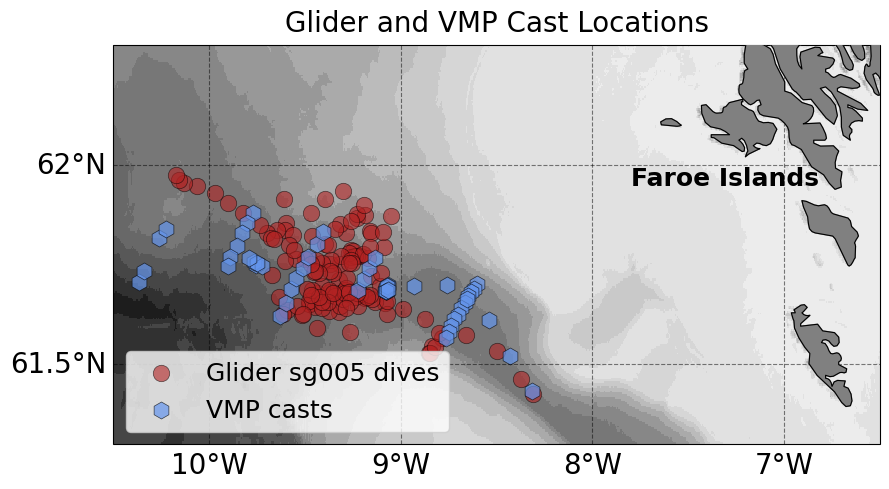

In [69]:
bathymetry = xr.open_dataset("/Users/tillmoritz/Desktop/Master_thesis/Data/Bathymetry/GEBCO_2024_IFR.nc")
plotting_style = "/Users/tillmoritz/Desktop/Master_thesis/Git/dissipationSML/dissipationSML/plotting.mplstyle"

        

latitudes = ds_sg005.LATITUDE.groupby(ds_sg005.CAST).mean().values
longitudes = ds_sg005.LONGITUDE.groupby(ds_sg005.CAST).mean().values
times = ds_sg005.TIME.groupby(ds_sg005.CAST).mean().values
profile_numbers = ds_sg005.CAST.groupby(ds_sg005.CAST).mean().values

 # Data to plot
VMP_lat = ds_VMP.LATITUDE.groupby(ds_VMP.PROFILE_NUMBER).mean().values
VMP_lon = ds_VMP.LONGITUDE.groupby(ds_VMP.PROFILE_NUMBER).mean().values

# Set the colorbar mode: either 'TIME' or 'PROFILES'
#color_mode = 'TIME'

map_kw = ccrs.PlateCarree()
# Prepare figure and axis
with plt.style.context(plotting_style):
    fig, ax = plt.subplots(subplot_kw={"projection": map_kw}, figsize=(9, 5))

    # Bounding box
    lon_min, lon_max = -10.5, -6.5
    lat_min, lat_max = 61.3, 62.3
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=map_kw)
    ax.set_aspect("auto")

    # Bathymetry background
    bath = bathymetry.sel(lon=slice(lon_min, lon_max), lat=slice(lat_min, lat_max))
    levels, contour_levels, max_level = plotting.get_bathymetry_levels(bath,level_spacing=100)
    print(levels)
    base_cmap = plt.get_cmap("Greys")
    cmap_bath = mcolors.LinearSegmentedColormap.from_list("dark_greys", base_cmap(np.linspace(0.15, 0.9, len(levels))))
    norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=cmap_bath.N)
    ax.pcolormesh(
        bath.lon, bath.lat, abs(bath.elevation.values),
        cmap=cmap_bath, norm=norm, transform=ccrs.PlateCarree(), zorder=1
    )

    # Glider scatter
    ax.scatter(
        longitudes, latitudes,alpha=0.6,
        color="firebrick", s=140, marker='o', label="Glider sg005 dives", edgecolors="black", linewidths=0.5
    )

    ax.scatter(
        VMP_lon, VMP_lat,alpha=0.7,
        color="cornflowerblue", s=150, marker='h', label="VMP casts", edgecolors="black", linewidths=0.5
    )

    # Final plot settings
    ax.legend(loc='lower left', fontsize=18)

    ax.add_feature(cfeature.LAND, color="gray", zorder=10)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=11)

    # Gridlines
    gl = ax.gridlines(draw_labels=True, color="black", alpha=0.5, linestyle="--")
    gl.xlocator = mticker.FixedLocator([-11, -10, -9 , -8,-7, -6])
    gl.ylocator = mticker.FixedLocator([61.5, 62])
    #### make ticks bigger
    gl.xlabel_style = {'size': 20}
    gl.ylabel_style = {'size': 20}
    gl.top_labels = False
    gl.right_labels = False

    ax.text(x=-7.8, y=61.95, s="Faroe Islands", fontsize= 18,weight='bold',zorder = 100)

plt.title("Glider and VMP Cast Locations", fontsize=20, pad = 10)
plt.tight_layout()
plt.grid()
#plt.savefig(thesis_resources_path + '/Glider_VMP_Map.png', dpi=300, bbox_inches='tight')
plt.savefig("/Users/tillmoritz/Desktop/OSM/Glider_VMP_Map.png", dpi=300, bbox_inches='tight')
plt.show()

In [19]:
ds_VMP = tools.add_unsorted_N(ds_VMP, var_rho='SIGTHETA')

  0%|          | 0/62 [00:00<?, ?it/s]

100%|██████████| 62/62 [00:00<00:00, 91.71it/s] 


In [25]:
ds_sg005['SIGTHETA'] = ds_sg005['SIGMA_T']
ds_sg005['EPSILON'] = ds_sg005['DISSIPATION_LEM']

In [38]:
vars_sg005 = ["SIGTHETA","SORTED_N","VELOCITY_SCALE","EPSILON"]
vars_VMP = ["SIGTHETA","N","EPSILON"]

binsize = 5
dict_gl = {}
dict_vmp = {}
for var in vars_VMP:
    ### look only at depth greater than 1000m
    ds_VMP_var = ds_VMP.where(ds_VMP.DEPTH <= 1000, drop=True)
    if var in ["EPSILON"]:
        var_VMP,depth,YI = tools.avg_profiles(ds_VMP_var, var, binsize=binsize, HAB=False, log=True)
        var_HAB, depth_HAB,YI_HAB = tools.avg_profiles(ds_VMP_var, var, binsize=binsize, HAB=True, log=True)
        ## interpolate the data to a regular depth grid between 40 m to 1000 m
        depth_new = np.arange(10,1000,binsize)
        var_VMP_new = np.interp(depth_new, depth.flatten(), var_VMP.flatten())
        depth_HAB_new = np.arange(10,500,binsize)
        var_HAB_new = np.interp(depth_HAB_new, depth_HAB.flatten(), var_HAB.flatten())
        dict_vmp[var] = 10**var_VMP_new,depth_new
        dict_vmp[var + '_HAB'] = 10**var_HAB_new, depth_HAB_new
    else:
        var_VMP,depth,YI = tools.avg_profiles(ds_VMP_var, var, binsize=binsize, HAB=False)
        var_HAB, depth_HAB,YI_HAB = tools.avg_profiles(ds_VMP_var, var, binsize=binsize, HAB=True)
        dict_vmp[var] = var_VMP,depth
        dict_vmp[var + '_HAB'] = var_HAB, depth_HAB
for var in vars_sg005:
    if var in ["EPSILON","VELOCITY_SCALE","SORTED_N"]:
        var_gl,depth,YI = tools.avg_profiles(ds_sg005, var, binsize=binsize, HAB=False, log=True)
        var_HAB, depth_HAB,YI_HAB = tools.avg_profiles(ds_sg005, var, binsize=binsize, HAB=True, log=True)
        dict_gl[var] = 10**var_gl,depth
        dict_gl[var + '_HAB'] = 10**var_HAB, depth_HAB
        depth_new = np.arange(10,1000,binsize)
        var_gl_new = np.interp(depth_new, depth.flatten(), var_gl.flatten())
        depth_HAB_new = np.arange(10,500,binsize)
        var_HAB_new = np.interp(depth_HAB_new, depth_HAB.flatten(), var_HAB.flatten())
        dict_gl[var] = 10**var_gl_new,depth_new
        dict_gl[var + '_HAB'] = 10**var_HAB_new, depth_HAB_new
    else:
        var_gl,depth,YI = tools.avg_profiles(ds_sg005, var, binsize=binsize, HAB=False)
        var_HAB, depth_HAB,YI_HAB = tools.avg_profiles(ds_sg005, var, binsize=binsize, HAB=True)
        dict_gl[var] = var_gl,depth
        dict_gl[var + '_HAB'] = var_HAB, depth_HAB

In [39]:
## calculate c using a least square fit between 10 to 600 m
depth_mask = (dict_gl['EPSILON'][1] >= 10) & (dict_gl['EPSILON'][1] <= 600)
e = dict_gl['EPSILON'][0][depth_mask]
epsilon = dict_vmp['EPSILON'][0][depth_mask]
c = np.sum(e * epsilon) / np.sum(e**2)
print("Calculated c:", c)

Calculated c: 0.8564520617753595


In [40]:
dict_gl['EPSILON'] = (dict_gl['EPSILON'][0]*c, dict_gl['EPSILON'][1])
dict_gl['EPSILON_HAB'] = (dict_gl['EPSILON_HAB'][0]*c, dict_gl['EPSILON_HAB'][1])

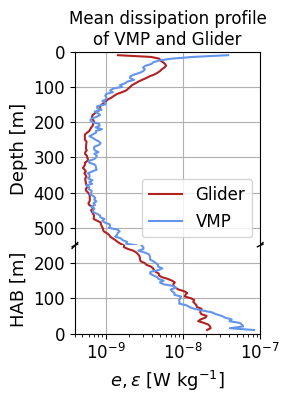

In [66]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# --- Settings ---
depth_upper_plot = 550
bottom_thickness = 250

var = "EPSILON"
xlabel = r"$e, \varepsilon$ [W kg$^{-1}$]"

with plt.style.context(plotting_style):

    # Wider figure now
    fig, ax = plt.subplots(1, 1, figsize=(3, 5), sharey=True)

    # Create inset HAB section
    ratio = bottom_thickness / depth_upper_plot
    ax_bottom = ax.inset_axes([0, -ratio, 1, ratio], sharex=ax)

    # --- Extract data ---
    var_gl, depth_gl = dict_gl[var]
    var_gl_HAB, depth_gl_HAB = dict_gl[var + "_HAB"]

    var_vmp, depth_vmp = dict_vmp[var]
    var_vmp_HAB, depth_vmp_HAB = dict_vmp[var + "_HAB"]

    # --- Upper section (0–550 m, full depth range) ---
    ax.plot(var_gl, depth_gl, 'firebrick', lw=1.5, label="Glider")
    ax.plot(var_vmp, depth_vmp, 'cornflowerblue', lw=1.5, label="VMP")

    ax.invert_yaxis()
    ax.set_ylim(depth_upper_plot, 0)
    ax.grid(True)

    # --- HAB section (0–250 m) ---
    ax_bottom.plot(var_gl_HAB, depth_gl_HAB, 'firebrick', lw=1.5)
    ax_bottom.plot(var_vmp_HAB, depth_vmp_HAB, 'cornflowerblue', lw=1.5)

    ax_bottom.invert_yaxis()
    ax_bottom.set_ylim(0, bottom_thickness)
    ax_bottom.grid(True)

    # --- Diagonal axis break ---
    ax.spines['bottom'].set_visible(False)
    ax_bottom.spines['top'].set_visible(False)

    d = .015
    kwargs = dict(transform=ax.transAxes, color='k', clip_on=False)
    ax.plot((-d, +d), (-d, +d), **kwargs)
    ax.plot((1 - d, 1 + d), (-d, +d), **kwargs)

    kwargs.update(transform=ax_bottom.transAxes)
    ax_bottom.plot((-d, +d), (1 - d, 1 + d), **kwargs)
    ax_bottom.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

    # --- Format axes ---
    ax.yaxis.set_major_locator(mticker.MultipleLocator(100))
    ax_bottom.yaxis.set_major_locator(mticker.MultipleLocator(100))

    ax.set_ylabel("Depth [m]", fontsize=13)
    ax_bottom.set_ylabel("HAB [m]", fontsize=13)
    ax_bottom.set_xlabel(xlabel, fontsize=13)

    # Log-scaling for dissipation
    ax.set_xscale("log")
    ax_bottom.set_xscale("log")

    # Use same dissipation range as before
    ax.set_xlim(4e-10, 1e-7)

    # Legend
    ax.legend(loc="lower right", fontsize=12)

    ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

plt.title("Mean dissipation profile\nof VMP and Glider", fontsize=12, pad=5)
plt.tight_layout()
plt.savefig('/Users/tillmoritz/Desktop/OSM/Dissipation_Profile.png',
            dpi=300, bbox_inches='tight')
plt.show()


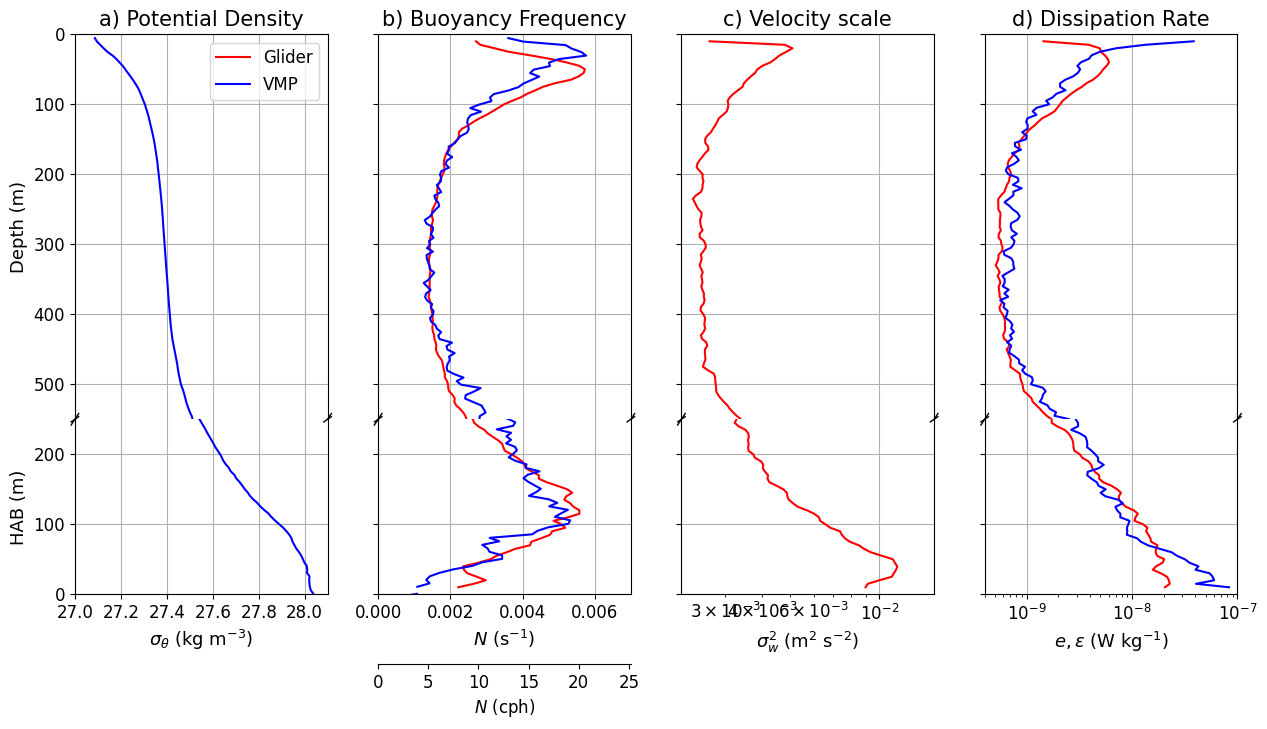

In [41]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Depth configuration
depth_upper_plot = 550
bottom_thickness = 250

# Which variables to compare
plot_vars = [
    ("SIGTHETA", r"$\sigma_\theta$ (kg m$^{-3}$)"),
    ("N", r"$N$ (s$^{-1}$)"),
    ("VELOCITY_SCALE", r"$\sigma_w^2$ (m$^2$ s$^{-2}$)"),
    ("EPSILON", r"$e, \varepsilon$ (W kg$^{-1}$)")
]

with plt.style.context(plotting_style):
    fig, axes = plt.subplots(1,len(plot_vars), figsize=(15, 5), sharey=True)

    for i, (var, xlabel) in enumerate(plot_vars):
        ax = axes[i]

        # Create inset for HAB section
        ratio = bottom_thickness / depth_upper_plot
        ax_bottom = ax.inset_axes([0, -ratio, 1, ratio], sharex=ax)

        # --- Extract data ---
        var_gl_key = var if var in dict_gl else ("SORTED_N" if var == "N" else var)
        var_gl_HAB_key = var_gl_key + "_HAB"

        var_gl, depth_gl = dict_gl[var_gl_key]
        var_gl_HAB, depth_gl_HAB = dict_gl[var_gl_HAB_key]

        # only handle the data, if var is not SIGMA_W2
        if var in ["SIGTHETA", "N", "EPSILON"]:
            var_vmp_key = var if var in dict_vmp else ("EPSILON" if var == "E_GL" else var)
            var_vmp_HAB_key = var_vmp_key + "_HAB"

            var_vmp, depth_vmp = dict_vmp[var_vmp_key]
            var_vmp_HAB, depth_vmp_HAB = dict_vmp[var_vmp_HAB_key]

        # --- Upper section (0–550 m) ---
        if var == "SIGTHETA":
            ax.plot(var_gl-1000, depth_gl, 'r', lw=1.5, label="Glider")
        else:
            ax.plot(var_gl, depth_gl, 'r', lw=1.5, label="Glider")
        if var in ["SIGTHETA", "N", "EPSILON"]:
            ax.plot(var_vmp, depth_vmp, 'b', lw=1.5, label="VMP")
        ax.invert_yaxis()
        ax.set_ylim(depth_upper_plot, 0)
        ax.grid(True)

        # --- Lower HAB section (0–250 m) ---
        if var == "SIGTHETA":
            ax_bottom.plot(var_gl_HAB-1000, depth_gl_HAB, 'r', lw=1.5)
        else:
            ax_bottom.plot(var_gl_HAB, depth_gl_HAB, 'r', lw=1.5)
        if var in ["SIGTHETA", "N", "EPSILON"]:
            ax_bottom.plot(var_vmp_HAB, depth_vmp_HAB, 'b', lw=1.5)
        ax_bottom.invert_yaxis()
        ax_bottom.set_ylim(0, bottom_thickness)
        ax_bottom.grid(True)

        # --- Spines and diagonal break ---
        ax.spines['bottom'].set_visible(False)
        ax_bottom.spines['top'].set_visible(False)
        d = .015
        kwargs = dict(transform=ax.transAxes, color='k', clip_on=False)
        ax.plot((-d, +d), (-d, +d), **kwargs)
        ax.plot((1 - d, 1 + d), (-d, +d), **kwargs)
        kwargs.update(transform=ax_bottom.transAxes)
        ax_bottom.plot((-d, +d), (1 - d, 1 + d), **kwargs)
        ax_bottom.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

        if var == "N":
            ax_sec = ax_bottom.secondary_xaxis('bottom', functions=(lambda x: x*3600, lambda x: x/3600))
             # Move the secondary axis down
            ax_sec.spines['bottom'].set_position(('outward', 50))  # 40 points outward
            ax_sec.set_xlabel(r'$N$ (cph)', fontsize=12)

        ax.yaxis.set_major_locator(mticker.MultipleLocator(100))
        ax_bottom.yaxis.set_major_locator(mticker.MultipleLocator(100))
        if i == 0:
            ax.set_ylabel("Depth (m)", fontsize=13)
            ax_bottom.set_ylabel("HAB (m)", fontsize=13)
        else:    
            ax_bottom.set_yticklabels([])
        ax_bottom.set_xlabel(xlabel, fontsize=13)

        # --- Scaling per variable (optional) ---
        if var in ["E_GL", "EPSILON"]:
            ax.set_xscale("log")
            ax_bottom.set_xscale("log")
        

        # --- Legend only once ---
        if i == 0:
            ax.legend(loc="upper right")

axes[0].set_title("a) Potential Density", fontsize=15)
axes[1].set_title("b) Buoyancy Frequency", fontsize=15)
axes[2].set_title("c) Velocity scale", fontsize=15)
axes[3].set_title("d) Dissipation Rate", fontsize=15)

### set xlim to between 0 and 0.007 for buoyancy frequency and make the ticks with 
axes[0].set_xlim(27, 28.1)
axes[1].set_xlim(0, 0.007)
axes[2].set_xscale("log")
axes[-1].set_xlim(4e-10, 1e-7)

# Hide x-ticks and labels of upper (main) plots
for ax in axes:
    ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)


plt.savefig(thesis_resources_path + '/Glider_VMP_Profiles.png', dpi=300, bbox_inches='tight')
plt.show()

In [80]:
boundary_AL_VMP = tools.find_boundary_AL(ds_VMP)
boundary_OL_VMP = tools.find_boundary_OL(ds_VMP)
boundary_AL_sg005 = tools.find_boundary_AL(ds_sg005)
boundary_OL_sg005 = tools.find_boundary_OL(ds_sg005)

  0%|          | 0/62 [00:00<?, ?it/s]

 14%|█▎        | 37/272 [00:00<00:01, 121.99it/s]/Users/tillmoritz/miniconda3/envs/dissipationSML/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:1307: RuntimeWarning: divide by zero encountered in divide
  a = -(dx2)/(dx1 * (dx1 + dx2))
/Users/tillmoritz/miniconda3/envs/dissipationSML/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:1308: RuntimeWarning: divide by zero encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
/Users/tillmoritz/miniconda3/envs/dissipationSML/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:1309: RuntimeWarning: divide by zero encountered in divide
  c = dx1 / (dx2 * (dx1 + dx2))
/Users/tillmoritz/miniconda3/envs/dissipationSML/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:1315: RuntimeWarning: invalid value encountered in add
  out[tuple(slice1)] = a * f[tuple(slice2)] + b * f[tuple(slice3)] + c * f[tuple(slice4)]
 39%|███▉      | 106/272 [00:00<00:01, 130.33it/s]/Users/tillmoritz/miniconda3/envs/diss

mld_df_VMP = tools.compute_mld(ds_flat,variable='SIGTHETA', method='threshold', threshold=0.03, ref_depth=30)
mld_VMP = mld_df_VMP['MLD'].values
mld_df_sg005 = tools.compute_mld(ds_sg005,variable='SIGTHETA', method='threshold', threshold=0.03, ref_depth=30)
mld_sg005 = mld_df_sg005['MLD'].values

In [511]:
profiles_VMP = np.unique(ds_VMP.PROFILE_NUMBER)
profiles_sg005 = np.unique(ds_sg005.PROFILE_NUMBER)

[(1000.0, 0.0), (1000.0, 0.0), (1000.0, 0.0)]

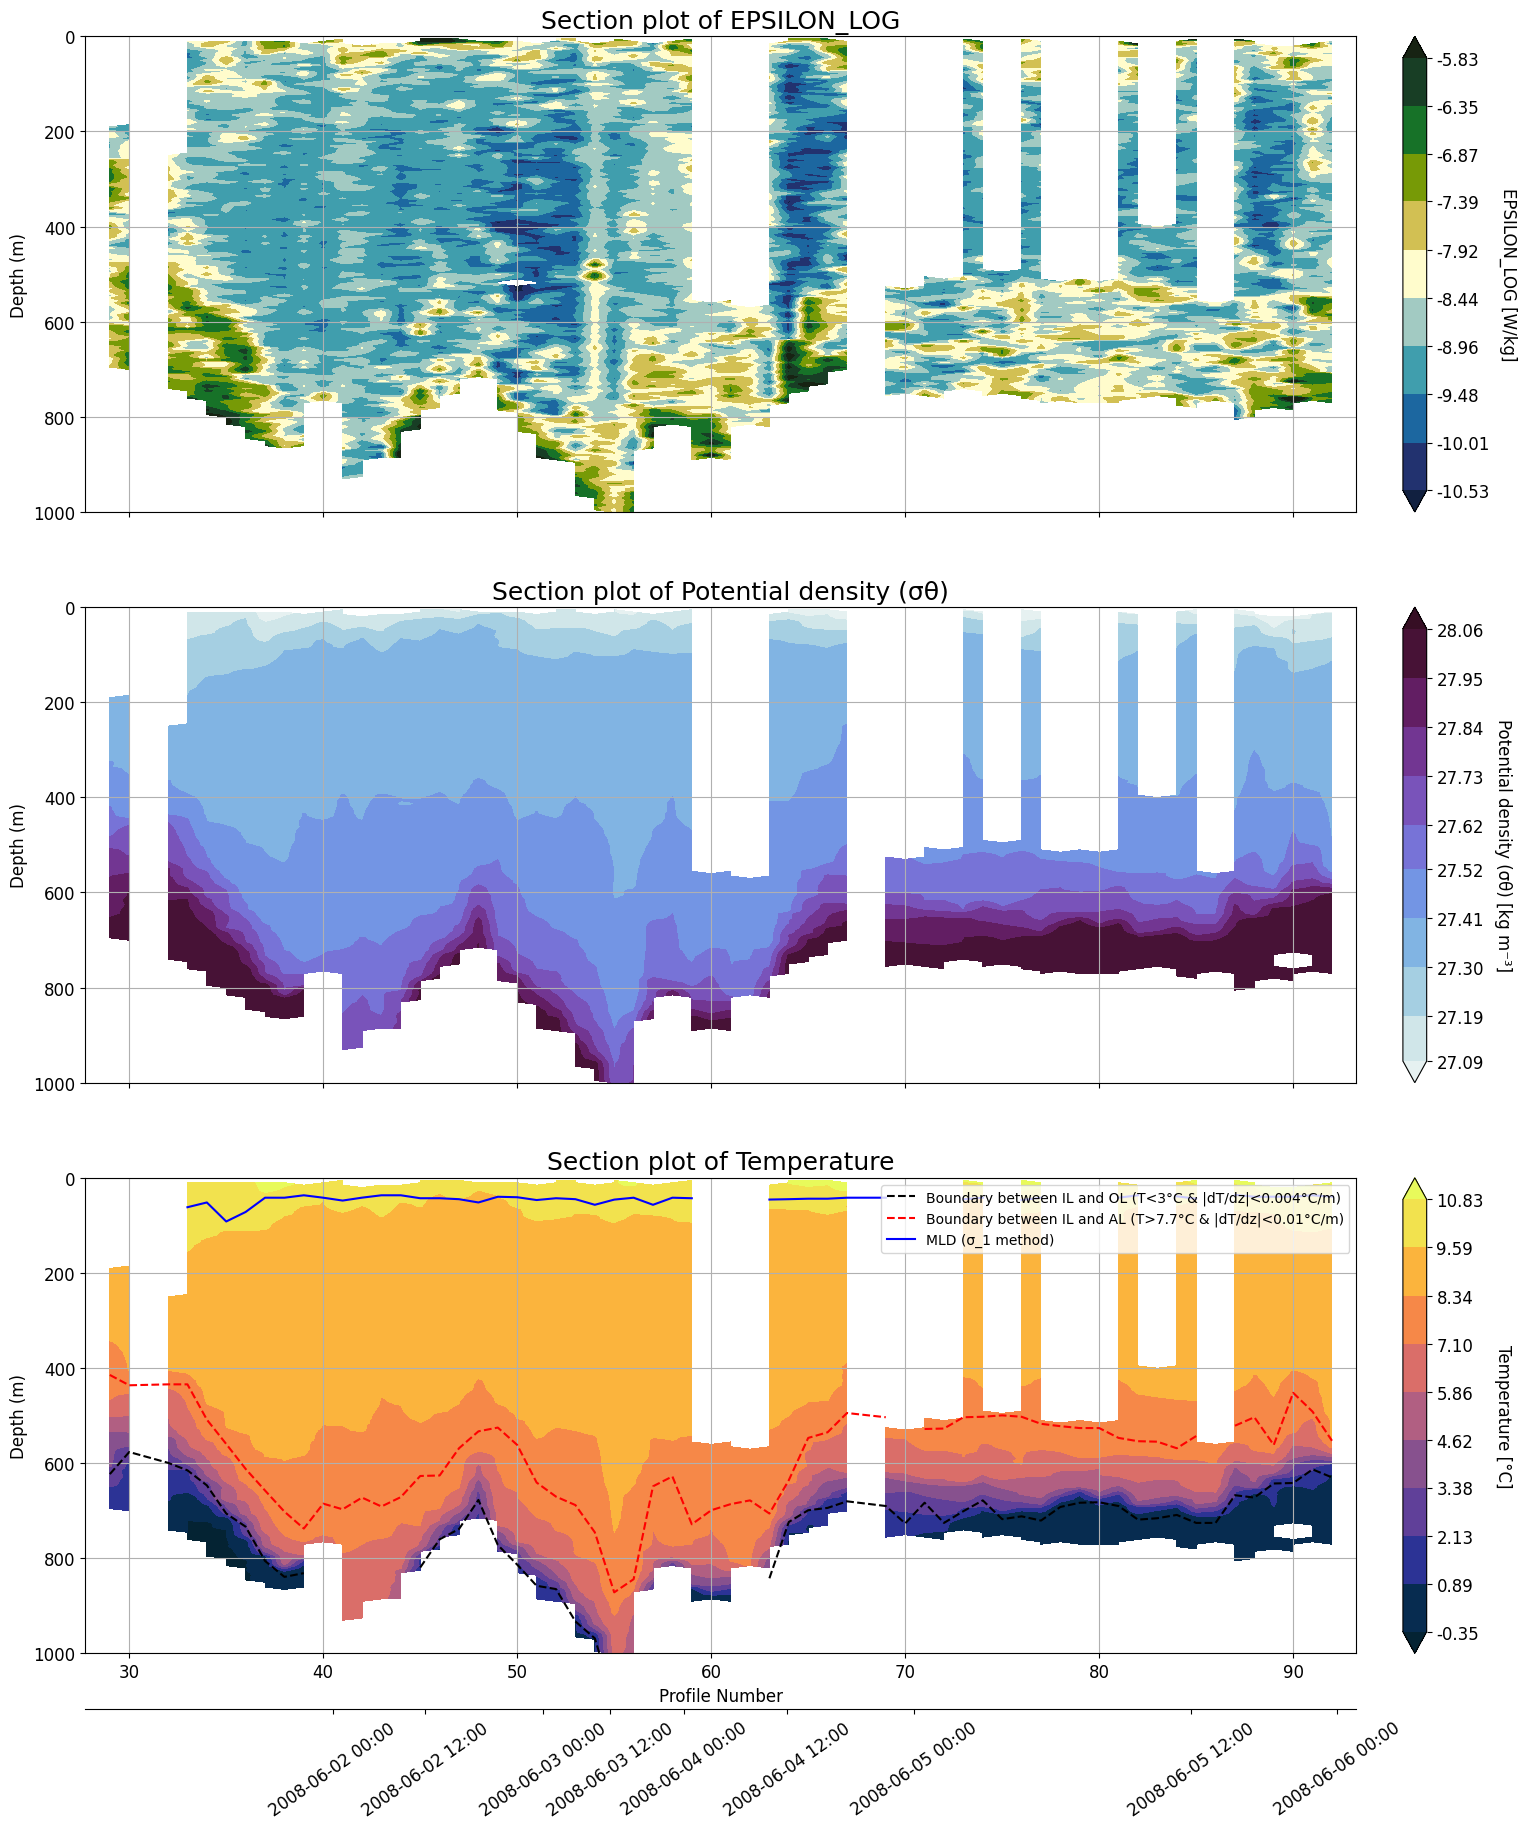

In [69]:
start = 30
end = 50
start = None
end = None

fig, ax = plotting.plot_section(ds_VMP, vars=['EPSILON_LOG','SIGTHETA','TEMP'], v_res=5,start=start, end = end, levels=True)

# add the temperature boundary to the last subplot
ax[-1].plot(profiles_VMP, boundary_OL_VMP, 'k--', label='Boundary between IL and OL (T<3°C & |dT/dz|<0.004°C/m)')
ax[-1].plot(profiles_VMP, boundary_AL_VMP, 'r--', label='Boundary between IL and AL (T>7.7°C & |dT/dz|<0.01°C/m)')
#ax[-1].plot(profiles_VMP, mld_VMP, 'b-', label='MLD (σ_1 method)')
ax[-1].legend(loc='upper right')
[ax[i].set_ylim(1000, 0) for i in range(len(ax))]

In [15]:
var_e_log = 'E_GL_LOG'#'DISSIPATION_LEM_LOG'
var_e = 'E_GL'#'DISSIPATION_LEM'

In [1]:
start = 30
end = 50
start = None
end = None
levels = levels = [-6,-6.4,-6.8,-7.2,-7.6,-8,-8.4,-8.8,-9.2,-9.6]
fig, ax = plotting.plot_section(ds_sg005, vars=[var_e_log], v_res=5,start=start, end = end, levels=levels)
fig, ax = plotting.plot_section(ds_sg005, vars=['SIGTHETA','TEMP'], v_res=5,start=start, end = end, levels=True)

# add the temperature boundary to the last subplot
#ax[-1].plot(profiles_sg005, boundary_OL_sg005, 'k--', label='Boundary between IL and OL (T<3°C & |dT/dz|<0.004°C/m)')
#ax[-1].plot(profiles_sg005, boundary_AL_sg005, 'r--', label='Boundary between IL and AL (T>7.7°C & |dT/dz|<0.01°C/m)')
#ax[-1].plot(profiles_sg005, mld_sg005, 'b-', label='MLD (σ_1 method)')
ax[-1].legend(loc='upper right')

NameError: name 'plotting' is not defined

In [35]:
import numpy as np
import xarray as xr

def split_profiles_by_layers(ds_orig, boundary_OL, boundary_AL,OL_min_depth = 100, AL_min_depth = 50):
    """
    Splits profiles into four datasets:
    - Below OL
    - Above AL
    - Between AL and OL
    - Above MLD

    Parameters
    ----------
    ds : xarray.Dataset
        The input dataset containing profiles with DEPTH and PROFILE_NUMBER.
    boundary_OL : array-like
        Overflow layer depth thresholds, one per profile.
    boundary_AL : array-like
        Accumulation layer depth thresholds, one per profile.
    mld_VMP : array-like
        Mixed Layer Depth values, one per profile.

    Returns
    -------
    ds_OL : xarray.Dataset
        Concatenated dataset of values below OL.
    ds_AL : xarray.Dataset
        Concatenated dataset of values above AL.
    ds_IL : xarray.Dataset
        Concatenated dataset of values between AL and OL.
    ds_MLD : xarray.Dataset
        Concatenated dataset of values above MLD.
    """
    ds_below_OL = []
    ds_between = []
    ds_above_AL = []
    #ds_above_MLD = []
    msk = (ds_orig.DEPTH >= AL_min_depth) & (ds_orig.HAB >= OL_min_depth)
    if list(ds_orig.sizes.keys())[0] == "TIME":
        ds = ds_orig.sel(TIME=msk)
    elif list(ds_orig.sizes.keys())[0] == "N_MEASUREMENTS":
        ds = ds_orig.sel(N_MEASUREMENTS=msk)
    

    # Pick the concatenation dimension explicitly
    concat_dim = list(ds.dims)[0]  # Default to the first dimension

    profiles = np.unique(ds.PROFILE_NUMBER)

    # Loop over each profile
    for i, profile_i in enumerate(profiles):
        profile = ds.where(ds['PROFILE_NUMBER'] == profile_i, drop=True)
        ol = boundary_OL[i]
        al = boundary_AL[i]
        #mld = mld_VMP[i]

        # Below OL
        if not np.isnan(ol):
            below_ol = profile.where(profile['DEPTH'] >= ol, drop=True)
            if below_ol.sizes.get(concat_dim, 0) > 0:
                ds_below_OL.append(below_ol)

        # Above AL
        if not np.isnan(al):
            above_al = profile.where(profile['DEPTH'] <= al, drop=True)
            if above_al.sizes.get(concat_dim, 0) > 0:
                ds_above_AL.append(above_al)

        # Between AL and OL
        if not np.isnan(al):
            if np.isnan(ol):
                ol = profile['DEPTH'].max()  # Set OL to a value greater than max depth if NaN
            intermediate = profile.where((profile['DEPTH'] < ol) & (profile['DEPTH'] > al), drop=True)
            if intermediate.sizes.get(concat_dim, 0) > 0:
                ds_between.append(intermediate)

        # Above MLD
        #if not np.isnan(mld):
        #    above_mld = profile.where(profile['DEPTH'] <= mld, drop=True)
        #    if above_mld.sizes.get(concat_dim, 0) > 0:
        #        ds_above_MLD.append(above_mld)

    # Concatenate each layer back into a single dataset
    ds_OL  = xr.concat(ds_below_OL,  dim=concat_dim) if ds_below_OL  else None
    ds_AL  = xr.concat(ds_above_AL,  dim=concat_dim) if ds_above_AL  else None
    ds_IL  = xr.concat(ds_between,   dim=concat_dim) if ds_between   else None

    return ds, ds_OL, ds_AL, ds_IL, #ds_MLD


In [38]:
from dissipationSML import tools_new
importlib.reload(tools_new)
ds_VMP = tools_new.add_unsorted_N2(ds_VMP, var_rho='SIGTHETA')

  0%|          | 0/62 [00:00<?, ?it/s]/Users/tillmoritz/Desktop/Master_thesis/Git/dissipationSML/dissipationSML/tools_new.py:583: RuntimeWarning: invalid value encountered in sqrt
  if dz != 0:
/Users/tillmoritz/Desktop/Master_thesis/Git/dissipationSML/dissipationSML/tools_new.py:583: RuntimeWarning: invalid value encountered in sqrt
  if dz != 0:
/Users/tillmoritz/Desktop/Master_thesis/Git/dissipationSML/dissipationSML/tools_new.py:583: RuntimeWarning: invalid value encountered in sqrt
  if dz != 0:
/Users/tillmoritz/Desktop/Master_thesis/Git/dissipationSML/dissipationSML/tools_new.py:583: RuntimeWarning: invalid value encountered in sqrt
  if dz != 0:
/Users/tillmoritz/Desktop/Master_thesis/Git/dissipationSML/dissipationSML/tools_new.py:583: RuntimeWarning: invalid value encountered in sqrt
  if dz != 0:
/Users/tillmoritz/Desktop/Master_thesis/Git/dissipationSML/dissipationSML/tools_new.py:583: RuntimeWarning: invalid value encountered in sqrt
  if dz != 0:
/Users/tillmoritz/Desktop/

In [39]:
ds_all_VMP, ds_OL_VMP, ds_AL_VMP, ds_IL_VMP = split_profiles_by_layers(ds_VMP, boundary_OL_VMP,  boundary_AL_VMP)
ds_all_sg005, ds_OL_sg005, ds_AL_sg005, ds_IL_sg005 = split_profiles_by_layers(ds_sg005, boundary_OL_sg005, boundary_AL_sg005)


#fig, ax = plotting.plot_section(ds_OL_VMP, vars=['EPSILON_LOG','SIGTHETA','TEMP'], v_res=1,start=start, end = end, levels=True)
fig, ax = plotting.plot_section(ds_flat, vars=['EPSILON_LOG'], v_res=1,start=start, end = end, levels=True)
ax[-1].set_ylim(1000, 0)
ax[-1].set_xlim(profiles_VMP[0], profiles_VMP[-1])
# add the temperature boundary to the last subplot
ax[-1].plot(profiles_VMP, boundary_AL_VMP, 'k--', label='Temp Boundary (T<3°C & |dT/dz|<0.004°C/m)')
ax[-1].plot(profiles_VMP, mld_VMP, 'r-', label='MLD (σ_1 method)')
ax[-1].plot(profiles_VMP, boundary_OL_VMP, 'b--', label='Temp Boundary (T>7.7°C & |dT/dz|<0.01°C/m)')
ax[-1].legend(loc='upper right')

fig,ax = plotting.plot_section(ds_MLD_VMP, vars=['EPSILON_LOG'], v_res=1,start=start, end = end, levels=True)
ax[-1].set_ylim(1000, 0)
ax[-1].set_xlim(profiles_VMP[0], profiles_VMP[-1])
fig, ax = plotting.plot_section(ds_AL_VMP, vars=['EPSILON_LOG'], v_res=1,start=start, end = end, levels=True)
ax[-1].set_ylim(1000, 0)
ax[-1].set_xlim(profiles_VMP[0], profiles_VMP[-1])
fig, ax = plotting.plot_section(ds_IL_VMP, vars=['EPSILON_LOG'], v_res=1,start=start, end = end, levels=True)
ax[-1].set_ylim(1000, 0)
ax[-1].set_xlim(profiles_VMP[0], profiles_VMP[-1])
fig,ax = plotting.plot_section(ds_OL_VMP, vars=['EPSILON_LOG'], v_res=1,start=start, end = end, levels=True)
ax[-1].set_ylim(1000, 0)
ax[-1].set_xlim(profiles_VMP[0], profiles_VMP[-1])

In [43]:
## calculate c using a least square fit between 10 to 600 m
depth_mask = (dict_gl['E_GL'][1] >= 10) & (dict_gl['E_GL'][1] <= 600)
e = dict_gl['E_GL'][0][depth_mask]
epsilon = dict_vmp['EPSILON'][0][depth_mask]
c = np.sum(e * epsilon) / np.sum(e**2)

In [44]:
c

np.float64(1.0012857366724959)

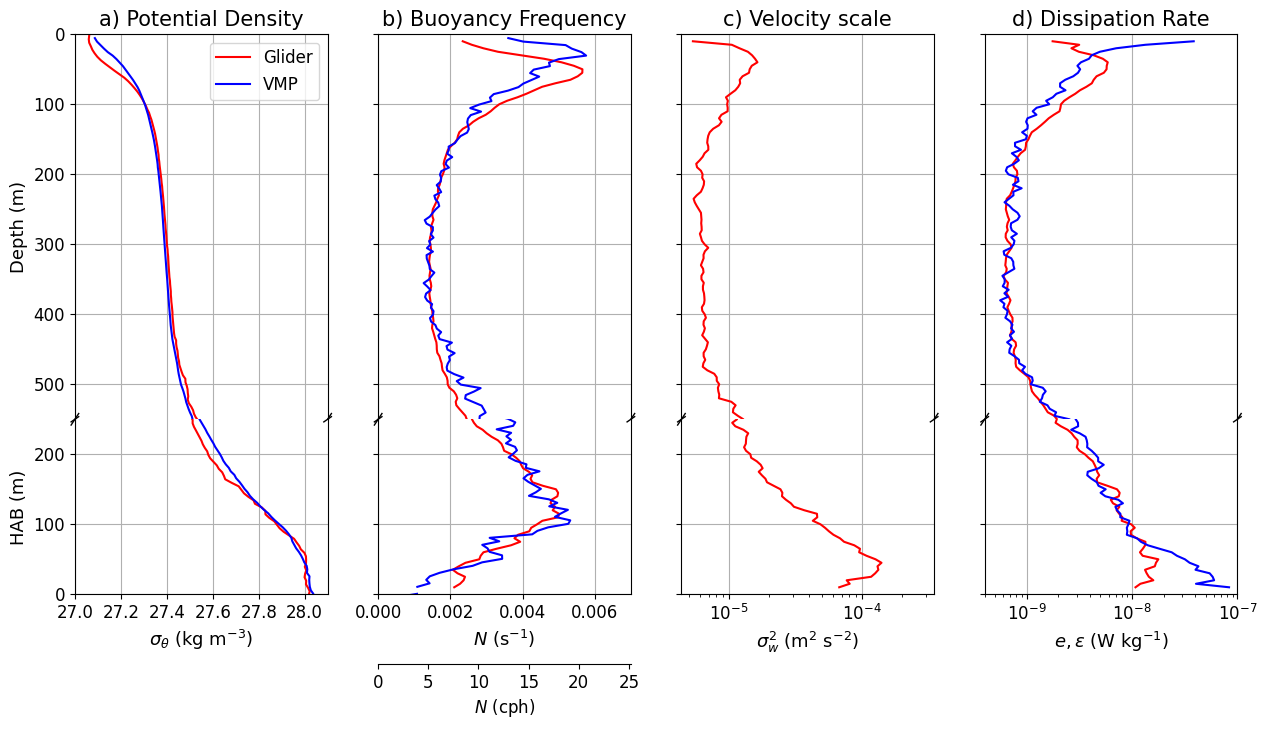

#fig, ax = plotting.plot_section(ds_OL_VMP, vars=['EPSILON_LOG','SIGTHETA','TEMP'], v_res=1,start=start, end = end, levels=True)
fig, ax = plotting.plot_section(ds_sg005, vars=['TEMP'], v_res=5,start=start, end = end, levels=True)
ax[-1].set_ylim(1000, 0)
# add the temperature boundary to the last subplot
ax[-1].plot(profiles_sg005, boundary_AL_sg005, 'k--', label='Temp Boundary (T<3°C & |dT/dz|<0.004°C/m)')
ax[-1].plot(profiles_sg005, mld_sg005, 'b--', label='MLD (σ_1 method)')
ax[-1].plot(profiles_sg005, boundary_OL_sg005, 'b--', label='Temp Boundary (T>7.7°C & |dT/dz|<0.01°C/m)')
ax[-1].legend()

fig,ax = plotting.plot_section(ds_MLD_sg005, vars=['DISSIPATION_LEM_LOG'], v_res=5,start=start, end = end, levels=True)
ax[-1].set_ylim(1000, 0)
fig, ax = plotting.plot_section(ds_AL_sg005, vars=['DISSIPATION_LEM_LOG'], v_res=5,start=start, end = end, levels=True)
ax[-1].set_ylim(1000, 0)
fig, ax = plotting.plot_section(ds_IL_sg005, vars=['DISSIPATION_LEM_LOG'], v_res=5,start=start, end = end, levels=True)
ax[-1].set_ylim(1000, 0)
fig,ax = plotting.plot_section(ds_OL_sg005, vars=['DISSIPATION_LEM_LOG'], v_res=5,start=start, end = end, levels=True)
ax[-1].set_ylim(1000, 0)

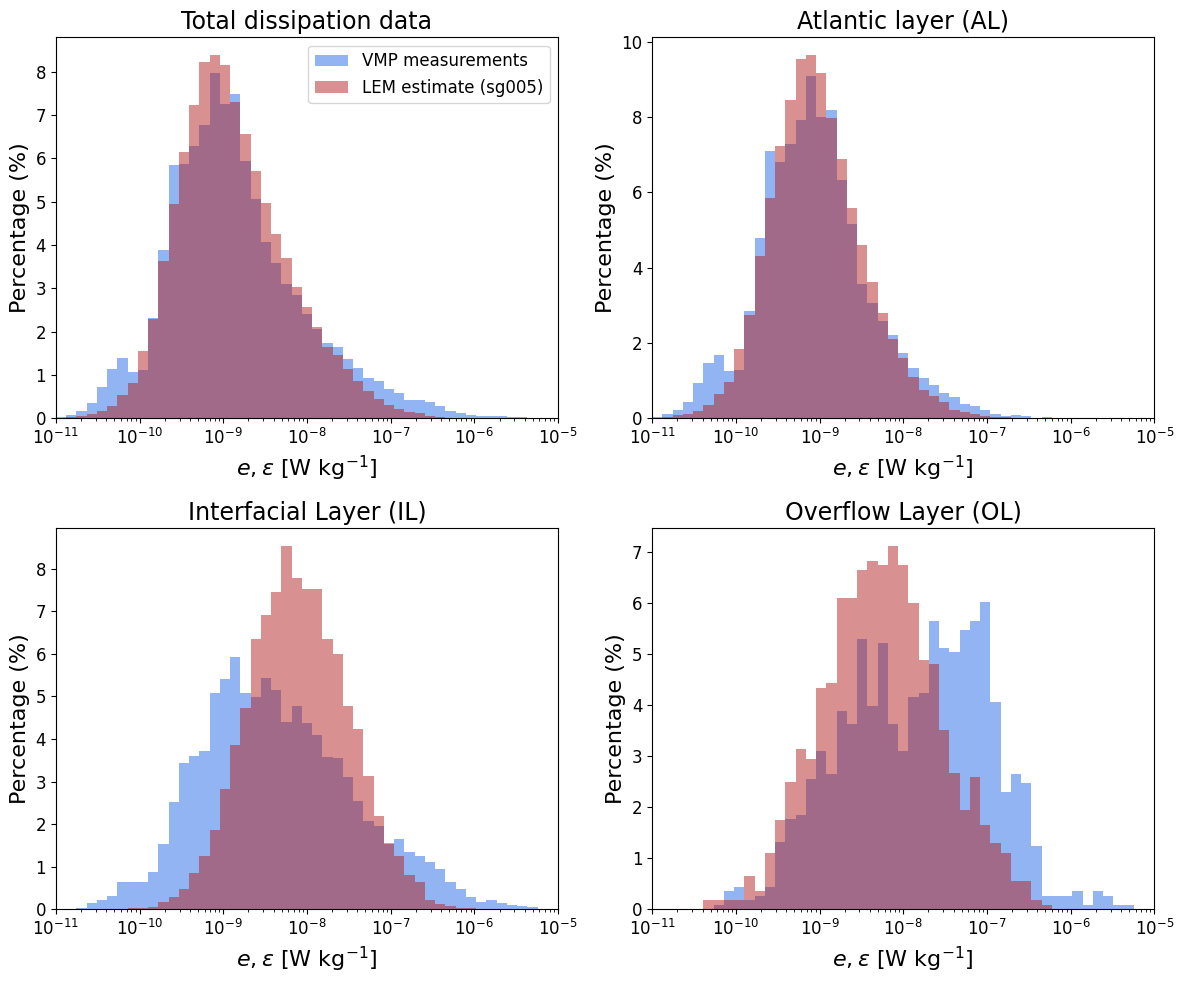

In [52]:
importlib.reload(plotting)

var_e = 'E_GL'#'DISSIPATION_LEM'
var_e2 = 'E_GL2'#'DISSIPATION_ORIGINAL'
with plt.style.context(plotting_style):
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()

    ### only look a
    #(ds_MLD_sg005, ds_MLD_VMP)
    i = 0
    for ds, ds_VMP in [(ds_all_sg005, ds_all_VMP), (ds_AL_sg005, ds_AL_VMP), (ds_IL_sg005, ds_IL_VMP), (ds_OL_sg005, ds_OL_VMP)]:
        ax = axes[i]
        bins = np.linspace(-11, -5, 50)
        bins = np.logspace(-11, -5, 50)
        plotting.plot_histogram(ds_VMP, vars=['EPSILON'], bins=bins, log_scale=False, style = "Percentage", ax=ax, alpha=0.7, color='cornflowerblue', label ='VMP measurements')
        plotting.plot_histogram(ds, vars=var_e, bins=bins, log_scale=False, style = "Percentage", ax=ax, alpha=0.5, color='firebrick',label='LEM estimate (sg005)')
        #plotting.plot_histogram(ds, vars=var_e2, bins=50, log_scale=True, style = "Percentage", ax=ax, alpha=0.5, color='green',label='sg005')
        i += 1
    axes[0].set_title('Total dissipation data',fontsize = 17)
    #axes[1].set_title('Mixed Layer (MLD)')
    axes[1].set_title('Atlantic layer (AL)',fontsize = 17)
    axes[2].set_title('Interfacial Layer (IL)',fontsize = 17)
    axes[3].set_title('Overflow Layer (OL)',fontsize = 17)

    [ax.set_xlabel(r'$e, \epsilon$ [W kg$^{-1}$]', fontsize = 16) for ax in axes]
    [ax.set_ylabel("Percentage (%)",fontsize = 16) for ax in axes]
    [ax.set_xscale('log') for ax in axes]
    [ax.set_xlim(1e-11, 1e-5) for ax in axes]
    axes[0].legend(fontsize=12)
    plt.tight_layout()

plt.savefig(thesis_resources_path + '/VMP_sg005_histogram.png', dpi=300, bbox_inches='tight')
plt.show()

In [53]:
ds_sg005 = xr.open_dataset(mission_path + '/dissipation_binned.nc')

### 3. Investigate surface conditions for the period of VMP and sg005

In [9]:
ERA5_basepath = '/Users/tillmoritz/Desktop/Master_thesis/Data/ERA-5/'

In [70]:
ds_ERA5 = xr.open_dataset(ERA5_basepath + '/ERA5_all_winds_fluxes_waves.nc')

In [71]:
ds_ERA5

<xarray.Dataset> Size: 1GB
Dimensions:     (valid_time: 27024, latitude: 21, longitude: 49)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 216kB 2006-11-01 ... 2009-11-30T2...
  * latitude    (latitude) float64 168B 60.0 60.25 60.5 ... 64.5 64.75 65.0
  * longitude   (longitude) float64 392B -15.0 -14.75 -14.5 ... -3.5 -3.25 -3.0
Data variables:
    tp          (valid_time, latitude, longitude) float32 111MB ...
    slhf        (valid_time, latitude, longitude) float32 111MB ...
    ssr         (valid_time, latitude, longitude) float32 111MB ...
    str         (valid_time, latitude, longitude) float32 111MB ...
    sshf        (valid_time, latitude, longitude) float32 111MB ...
    e           (valid_time, latitude, longitude) float32 111MB ...
    u10         (valid_time, latitude, longitude) float32 111MB ...
    v10         (valid_time, latitude, longitude) float32 111MB ...
    zust        (valid_time, latitude, longitude) float32 111MB ...
    swh         (valid_time, latitude, longitude) float32 111MB ...
    pp1d        (valid_time, latitude, longitude) float32 111MB ...
    TAU         (valid_time, latitude, longitude) float32 111MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-01-31T12:25 GRIB to CDM+CF via cfgrib-0.9.1...

In [118]:
importlib.reload(utilities)

<module 'dissipationSML.utilities' from '/Users/tillmoritz/Desktop/Master_thesis/Git/dissipationSML/dissipationSML/utilities.py'>

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def plot_ERA5_at_time(ds, time, variable):
    """
    Plots wind vectors (u10, v10) if variable is 'wind', 
    otherwise plots the chosen variable as colored markers with a colorbar.

    Parameters
    ----------
    ds : xarray.Dataset
        Dataset containing at least 'u10' and 'v10' for wind.
    time : str or pandas.Timestamp
        The time point for which data should be plotted.
    variable: str
        Variable to be plotted on the map. 
        Use 'wind' for quiver plot, or any other variable name for marker plot.

    Returns
    -------
    fig, ax : matplotlib figure and axis
    """
    # Select data for the specified time
    ds_at_time = ds.sel(valid_time=time)

    # Extract coordinates
    latitudes = ds['latitude'].values
    longitudes = ds['longitude'].values
    lon_grid, lat_grid = np.meshgrid(longitudes, latitudes)

    # Create figure and axis
    fig, ax = plt.subplots(figsize=(15, 8), subplot_kw={'projection': ccrs.PlateCarree()})
    ax.set_extent([longitudes.min()-1, longitudes.max()+1, latitudes.min()-1, latitudes.max()+1], 
                  crs=ccrs.PlateCarree())

    # Add map features
    ax.add_feature(cfeature.LAND, edgecolor='black')
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=":")

    cmap = utilities.get_colormap(variable)
    label = utilities.get_label(variable)

    # Plot based on variable type
    if variable.lower() == 'wind':
        # Extract wind components
        u = ds_at_time['u10'].values
        v = ds_at_time['v10'].values

        # Reshape if needed
        if u.ndim == 1:
            u = u.reshape(len(latitudes), len(longitudes))
            v = v.reshape(len(latitudes), len(longitudes))

        # Compute wind speed
        speed = np.sqrt(u**2 + v**2)

        unit = utilities.get_unit(ds,'u10')

        step = 1  # Downsample for clarity
        q = ax.quiver(
            lon_grid[::step, ::step], lat_grid[::step, ::step],
            u[::step, ::step], v[::step, ::step],
            speed[::step, ::step],  # Color by speed
            cmap=cmap, transform=ccrs.PlateCarree(), scale=1000
        )

        # Add colorbar for speed
        cbar = plt.colorbar(q, ax=ax, orientation='vertical', shrink=0.7)
        cbar.set_label(f"{label} ({unit})")

        ax.set_title(f"Wind Vectors at {time}")

    else:
        if variable not in ds.data_vars:
            raise ValueError(f"Variable '{variable}' not found in dataset.")
        
        norm = None
        if variable in ['ssr','slhf','str','sshf']:
            norm = mpl.colors.Normalize(vmin=-700, vmax=700)

        data = ds_at_time[variable].values
        sc = ax.scatter(lon_grid, lat_grid, c=data, cmap=cmap, 
                        transform=ccrs.PlateCarree(), marker='o',norm=norm)
        
        unit = utilities.get_unit(ds, variable)
        cbar = plt.colorbar(sc, ax=ax, orientation='vertical', shrink=0.7)
        cbar.set_label(f"{label} ({unit})")
        ax.set_title(f"{label} at {time}")

    # Gridlines
    gl = ax.gridlines(draw_labels=True, color='black', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False

    plt.show()
    return fig, ax


In [126]:
ds_ERA5

<xarray.Dataset> Size: 1GB
Dimensions:     (valid_time: 27024, latitude: 21, longitude: 49)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 216kB 2006-11-01 ... 2009-11-30T2...
  * latitude    (latitude) float64 168B 60.0 60.25 60.5 ... 64.5 64.75 65.0
  * longitude   (longitude) float64 392B -15.0 -14.75 -14.5 ... -3.5 -3.25 -3.0
Data variables:
    tp          (valid_time, latitude, longitude) float32 111MB ...
    slhf        (valid_time, latitude, longitude) float32 111MB ...
    ssr         (valid_time, latitude, longitude) float32 111MB ...
    str         (valid_time, latitude, longitude) float32 111MB ...
    sshf        (valid_time, latitude, longitude) float32 111MB ...
    e           (valid_time, latitude, longitude) float32 111MB ...
    u10         (valid_time, latitude, longitude) float32 111MB ...
    v10         (valid_time, latitude, longitude) float32 111MB ...
    zust        (valid_time, latitude, longitude) float32 111MB ...
    swh         (valid_time, latitude, longitude) float32 111MB ...
    pp1d        (valid_time, latitude, longitude) float32 111MB ...
    TAU         (valid_time, latitude, longitude) float32 111MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-01-31T12:25 GRIB to CDM+CF via cfgrib-0.9.1...

In [11]:
ds_ERA5 = ds_ERA5.sel(valid_time = slice('2008-06-01','2008-08-01'))

In [46]:
times = ds_ERA5.valid_time.values
time_bar = widgets.SelectionSlider(options=times,index=0)
var_options = ['wind'] + [var for var in ds_ERA5.data_vars if ds_ERA5[var].dtype.kind in {'i', 'f'}]
var_dropdown = widgets.Dropdown(options=var_options, value=var_options[0], description="Variable:")

ui = widgets.VBox([widgets.Label("Select time:"), time_bar,
                       widgets.Label("Select variable:"),var_dropdown])

def interactive_ERA5(time, variable):
    plot_ERA5_at_time(ds_ERA5,time= time,variable= variable)

# Create interactive plot
out = widgets.interactive_output(interactive_ERA5, {
        'time': time_bar,
        'variable': var_dropdown,})

display(ui,out)

Output()

In [15]:
ds_ERA5 = ds_ERA5.sel(valid_time = slice('2008-06-01','2008-07-01'))

In [16]:
ds_ERA5_10W = ds_ERA5.sel(longitude = -10)
ds_ERA5_63N = ds_ERA5.sel(latitude = 63)

/var/folders/_j/gtdz594n13z3y8k5ml71sv3r0000gn/T/ipykernel_37758/3460446555.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('coolwarm')


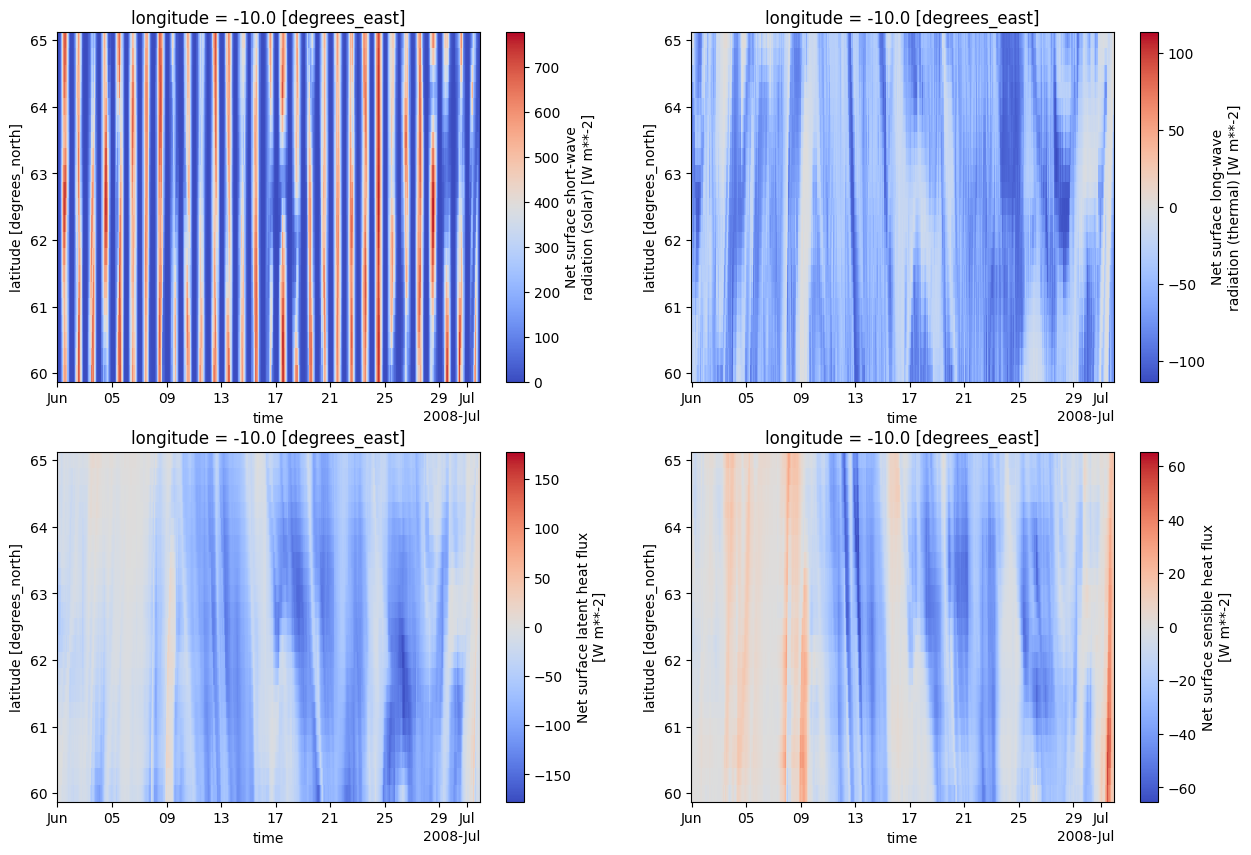

In [17]:
import cmocean.cm as cmo#
import matplotlib.cm as cm

fig, axs = plt.subplots(nrows=2, ncols=2,figsize = [15,10])
norm = None #mpl.colors.Normalize(vmin=-700, vmax=700)
cmap = cm.get_cmap('coolwarm')
ds_ERA5_10W['ssr'].plot(x='valid_time',y='latitude',norm=norm,cmap=cmap,ax=axs[0][0])
ds_ERA5_10W['str'].plot(x='valid_time',y='latitude',norm=norm,cmap=cmap,ax=axs[0][1])
ds_ERA5_10W['slhf'].plot(x='valid_time',y='latitude',norm=norm,cmap=cmap,ax=axs[1][0])
ds_ERA5_10W['sshf'].plot(x='valid_time',y='latitude',norm=norm,cmap=cmap,ax=axs[1][1])

/var/folders/_j/gtdz594n13z3y8k5ml71sv3r0000gn/T/ipykernel_37758/2125844742.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('coolwarm')


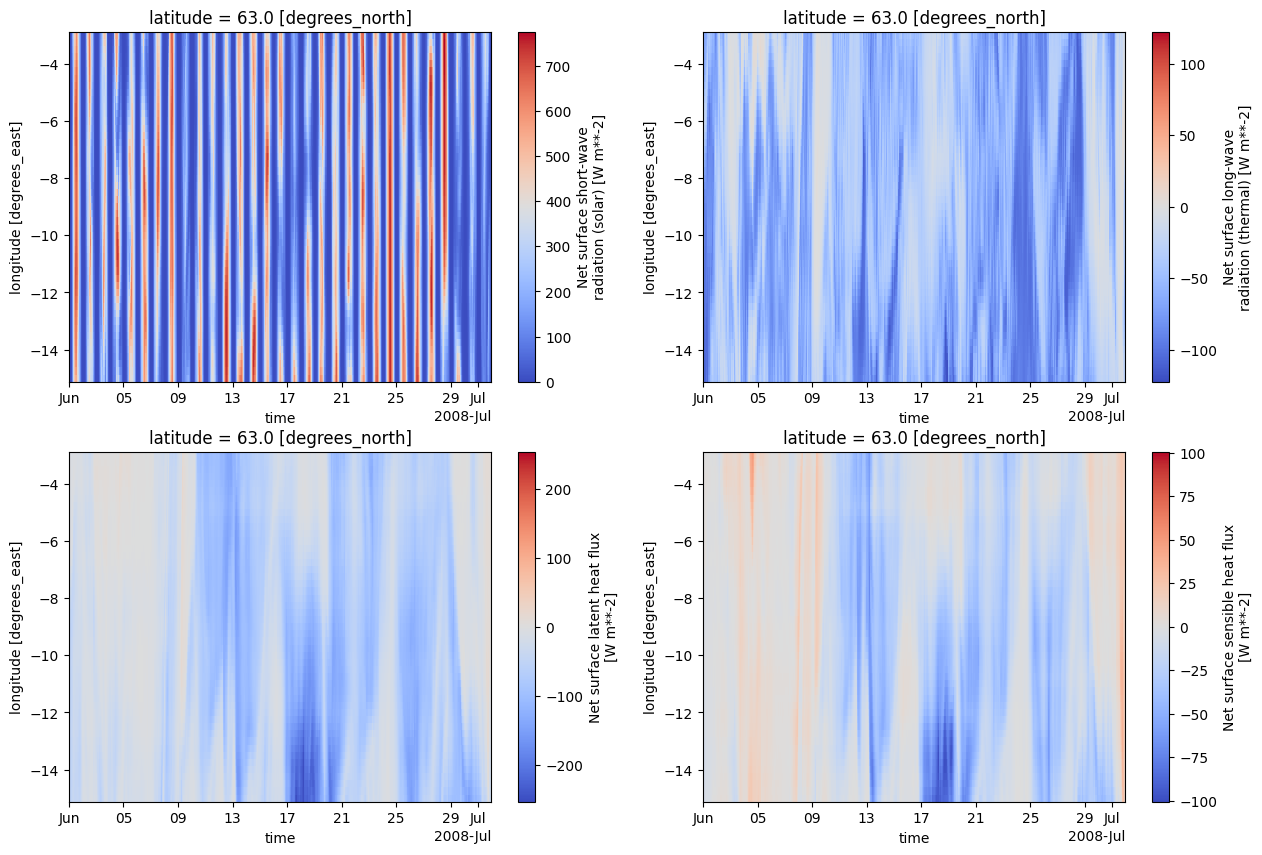

In [18]:
fig, axs = plt.subplots(nrows=2, ncols=2,figsize = [15,10])
norm = None #mpl.colors.Normalize(vmin=-700, vmax=700)
cmap = cm.get_cmap('coolwarm')
ds_ERA5_63N['ssr'].plot(x='valid_time',y='longitude',norm=norm,cmap=cmap,ax=axs[0][0])
ds_ERA5_63N['str'].plot(x='valid_time',y='longitude',norm=norm,cmap=cmap,ax=axs[0][1])
ds_ERA5_63N['slhf'].plot(x='valid_time',y='longitude',norm=norm,cmap=cmap,ax=axs[1][0])
ds_ERA5_63N['sshf'].plot(x='valid_time',y='longitude',norm=norm,cmap=cmap,ax=axs[1][1])

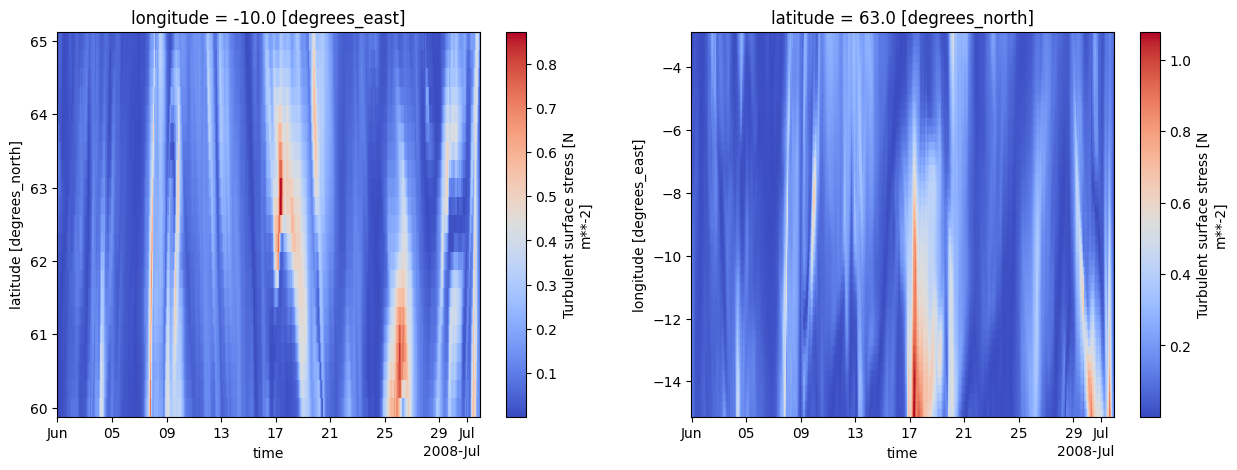

In [19]:
Tau_10W = ds_ERA5.sel(longitude = -10)
Tau_63N = ds_ERA5.sel(latitude = 63)
fig, axs = plt.subplots(nrows=1, ncols=2, figsize = [15,5])
Tau_10W['TAU'].plot(x='valid_time',y='latitude',cmap=cmap, ax = axs[0])
Tau_63N['TAU'].plot(x='valid_time',y='longitude',norm=norm,cmap=cmap,ax=axs[1])

In [77]:
def match_era5_to_mld(ds_mld, ds_era5, lon_range=None, lat_range=None, time_lag = None, time_range = None):
    """
    Match ERA5 data to MLD observations based on time, longitude, and latitude. 
    ERA5 values are averaged over a spatial range (if provided) and matched by nearest time.

    Parameters
    ----------
    ds_mld : xarray.Dataset
        Dataset with MLD observations and variables: TIME, LATITUDE, LONGITUDE.
    ds_era5 : xarray.Dataset
        ERA5 dataset with dimensions: valid_time, latitude, longitude.
    lon_range : float or None, optional
        Longitude range (in degrees) for spatial averaging. If None, uses nearest longitude.
    lat_range : float or None, optional
        Latitude range (in degrees) for spatial averaging. If None, uses nearest latitude.
    time_lag: float
        Take the profile time minus a time_lag [hours] for the matching of the ERA5 data.
    time_range: float
        Takes a time range [hours], in which the ERA5 data is averaged.

    Returns
    -------
    xarray.Dataset
        MLD dataset with ERA5 variables added as 1D arrays aligned with TIME.
    """
    times = ds_mld.TIME.values
    lons = ds_mld.LONGITUDE.values
    lats = ds_mld.LATITUDE.values

    if time_lag:
        times = times - np.timedelta64(time_lag,"h")

    matched_profiles = []

    for i in tqdm(range(len(times)), desc="Matching ERA5 to MLD"):
        time = times[i]
        lon = lons[i]
        lat = lats[i]

        if time_range:
            match = ds_era5.sel(valid_time=slice(time, time+np.timedelta64(time_range,'h')))
        else:
            # Select nearest ERA5 time
            match = ds_era5.sel(valid_time=time, method="nearest")

        # Apply spatial window if specified
        if lon_range:
            match = match.sel(longitude=slice(lon - lon_range, lon + lon_range))
        else:
            match = match.sel(longitude=slice(lon))

        if lat_range:
            match = match.sel(latitude=slice(lat - lat_range, lat + lat_range))
        else:
            match = match.sel(latitude=slice(lat))

        # Compute spatial mean and assign timestamp
        match = match.mean(dim=["latitude", "longitude"], skipna=True, keep_attrs=True)
        match = match.assign_coords(TIME=time)
        matched_profiles.append(match)

    # Combine matched ERA5 profiles into one dataset
    ds_matched = xr.concat(matched_profiles, dim="TIME")

    # Merge new ERA5 variables into the MLD dataset
    for var in ds_era5.data_vars:
        if var not in ds_mld:
            ds_mld[var] = ds_matched[var]

    # Store matching settings as metadata
    ds_mld.attrs["longitude_range_used"] = f"±{lon_range}°" if lon_range else "Nearest longitude"
    ds_mld.attrs["latitude_range_used"] = f"±{lat_range}°" if lat_range else "Nearest latitude"
    ds_mld.attrs["time_lag"] = f"{time_lag} hours" if time_lag else "Nearest point in time"

    return ds_mld

In [73]:
ds = xr.open_dataset(mission_path + '/all_data_OG1.nc')

In [74]:
mld = tools.compute_mld(ds, variable ='SIGMA_T')

In [75]:
ds_mld = utilities.df_to_ds(mld, folder = mission_path, glider_name= mission_path)

In [79]:
ds_ERA5

<xarray.Dataset> Size: 1GB
Dimensions:     (valid_time: 27024, latitude: 21, longitude: 49)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 216kB 2006-11-01 ... 2009-11-30T2...
  * latitude    (latitude) float64 168B 60.0 60.25 60.5 ... 64.5 64.75 65.0
  * longitude   (longitude) float64 392B -15.0 -14.75 -14.5 ... -3.5 -3.25 -3.0
Data variables:
    tp          (valid_time, latitude, longitude) float32 111MB ...
    slhf        (valid_time, latitude, longitude) float32 111MB ...
    ssr         (valid_time, latitude, longitude) float32 111MB ...
    str         (valid_time, latitude, longitude) float32 111MB ...
    sshf        (valid_time, latitude, longitude) float32 111MB ...
    e           (valid_time, latitude, longitude) float32 111MB ...
    u10         (valid_time, latitude, longitude) float32 111MB ...
    v10         (valid_time, latitude, longitude) float32 111MB ...
    zust        (valid_time, latitude, longitude) float32 111MB ...
    swh         (valid_time, latitude, longitude) float32 111MB ...
    pp1d        (valid_time, latitude, longitude) float32 111MB ...
    TAU         (valid_time, latitude, longitude) float32 111MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-01-31T12:25 GRIB to CDM+CF via cfgrib-0.9.1...

In [82]:
ds_mld = match_era5_to_mld(ds_mld, ds_ERA5, lon_range=0.25, lat_range=0.25, time_lag=5, time_range=5)

Matching ERA5 to MLD:   0%|          | 0/770 [00:00<?, ?it/s]

Matching ERA5 to MLD: 100%|██████████| 770/770 [00:04<00:00, 182.97it/s]
